# Assignment 1

In [194]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, ConfusionMatrixDisplay

In [195]:
#has 3 inputs --- easier dataset linearly seperable
blobs = pd.read_csv("blobs600.csv")
x_blobs = blobs.iloc[:, :-1]
y_blobs = blobs.iloc[:, -1]
print("blobs inputs length: " ,len(x_blobs))
print("blobs outputs length: " ,len(y_blobs))

#has 2 inputs 
circles = pd.read_csv("circles500.csv")
x_circles = circles.iloc[:, :-1]
y_circles = circles.iloc[:, -1]
print("circles inputs length: " , len(x_circles))
print("circles outputs length: " ,len(y_circles))

blobs inputs length:  600
blobs outputs length:  600
circles inputs length:  500
circles outputs length:  500


In [196]:
#better readablity used in multiple sections
def logReg(z):
    return 1 / ( 1 + (math.e)**(-z) )

def activaitonDer(input):
    log = logReg(input)
    return log * (1 - log)

def lossfunction(y, y_hat):
    return -( (y * math.log(y_hat)) + ((1-y) * math.log(1-y_hat)) )



In [197]:
# train = 70%
# test = 15%
# validaiton = 15%
X_train1, X_temp, y_train1, y_temp = train_test_split(x_blobs, y_blobs, test_size=0.3, random_state=39)
X_val1, X_test1, y_val1, y_test1 = train_test_split(X_temp, y_temp, test_size=0.5, random_state=39)

print("train size: ", len(X_train1))
print("Val size: ", len(X_val1))
print("test size: ", len(X_test1))

train size:  420
Val size:  90
test size:  90


In [198]:
# train = 70%
# test = 15%
# validaiton = 15%
X_train2, X_temp, y_train2, y_temp = train_test_split(x_circles, y_circles, test_size=0.3, random_state=39)
X_val2, X_test2, y_val2, y_test2 = train_test_split(X_temp, y_temp, test_size=0.5, random_state=39)

print("train size: ", len(X_train2))
print("Val size: ", len(X_val2))
print("test size: ", len(X_test2))

train size:  350
Val size:  75
test size:  75


## Task 1

Implement a Nueral Networks based approach to Lgoistic regression

In [199]:

# version 1 calculation of only a single y_hat, (like in slides from lecture) 
def LogRegNN( X, Y):
    #set up for logistic regression
    alpha = 0.05
    max_iters = 100000
    threshold = 0.01
    N = X.shape[0]

    y_output = [] 

    #weights and bias
    #random generation
    weights = [0] * X.shape[1]
    for i,_ in enumerate(weights):
        weights[i] = np.random.uniform(0,0.01)
    #print("weights: ", weights)

    bias=np.random.uniform(0,0.01)

    #stopping criteria
    going = True
    J_running = 0
    J_running_prev=0
    iteration = 0

    while(going):
        chosenIndex = np.random.randint(0,len(X))

        xi = X.iloc[chosenIndex]
        yi = Y.iloc[chosenIndex]

        z = np.dot(weights, xi) + bias
        y_hat = logReg(z)
        
        #J_current is the loss function
        J_current = lossfunction(yi, y_hat)

        #gradient descent ========================================
        deltaW = [0] * X.shape[1]
        deltaB = 0

        #delta loop
        for j,_ in enumerate(weights):
            deltaW[j] = (y_hat - yi) * xi.iloc[j]

        deltaB = y_hat - yi
            
        #actual update loop 
        for j,_ in enumerate(weights):
            weights[j] = weights[j] - (alpha * deltaW[j])

        bias = bias - (alpha * deltaB) 
            
        
        #stopping criterai
        iteration +=1
        if(iteration > max_iters):
            going = False

        J_running += J_current
        
        if (iteration%N == 0):
            if (abs(J_running - J_running_prev) < threshold):
                going = False
            #print(J_running, " for iteration ", iteration)
            J_running_prev = J_running
            J_running = 0;

    print("===================================================================================")
    print(weights)
    print(bias)
    print("===================================================================================")
    
    # finalise output
    # predict values
    #using final wieghgts and bias
    X = np.array(X)

    for row in X:
        z = np.dot(row, weights) + bias
        y_hat = logReg(z)
        #print(y_hat)
        if y_hat < 0.5:
            y_output.append(0)
        else:
            y_output.append(1)
        
    print("iters: " , iteration)
    

    
    #print("final chosen index: ",chosenIndex)
    #print("final z: ", z)
    #print("final Y_hat: ", y_hat)
    #print("final y at chosen location: ", Y.iloc[chosenIndex])
    #print("final loss func: ",lossfunction(Y.iloc[chosenIndex], y_hat))
    #print(len(predictedOut))
    #print("circles: ", x_circles.iloc[499])
    #print("function values: " ,function)
    #print(predictedOut)
    return y_output #reutrn all the 1s and 0s

x = LogRegNN(x_blobs, y_blobs)

[np.float64(5.314690005994702), np.float64(4.696846187641709), np.float64(3.659684325729035)]
0.32295915149392457
iters:  100001


## Task 2

need to actually predict, best to make a class so weights can be saved

In [200]:
class LogRegNNet:
    
    #setup params for model
    def __init__(self,alpha, max_iters, threshold):
        self.alpha = alpha
        self.max_iters = max_iters
        self.threshold = threshold
        self.weights = 0
        self.bias = 0
        
         
         
    # here we will train on out data
    # outputs will be the weights and bias
    # so that they can be used later for prediction
    def train(self, X, Y):
        #X and Y here are they training data
        N = X.shape[0] # number amount of data (i.e gives every point the chance to be hit in sgd, could theortically hit all datapoints)

        #weights and bias
        #random generation
        weights = [0] * X.shape[1]
        for i,_ in enumerate(weights):
            weights[i] = np.random.uniform(0,0.01)
        
        bias=np.random.uniform(0,0.01)

        #stopping criteria
        going = True
        J_running = 0
        J_running_prev=0
        iteration = 0

        while(going):
            chosenIndex = np.random.randint(0,len(X))

            xi = X.iloc[chosenIndex]
            yi = Y.iloc[chosenIndex]

            z = np.dot(weights, xi) + bias
            y_hat = logReg(z)
        
            #J_current is the loss function
            J_current = lossfunction(yi, y_hat)

            #gradient descent ========================================
            deltaW = [0] * X.shape[1]
            deltaB = 0

            #delta loop
            for j,_ in enumerate(weights):
                deltaW[j] = (y_hat - yi) * xi.iloc[j]

            deltaB = y_hat - yi
            
                #actual update loop 
            for j,_ in enumerate(weights):
                weights[j] = weights[j] - (self.alpha * deltaW[j])

            bias = bias - (self.alpha * deltaB) 
            
        
                #stopping criterai
            iteration +=1
            if(iteration > self.max_iters):
                going = False

            J_running += J_current
        
            if (iteration%N == 0):
                if (abs(J_running - J_running_prev) < self.threshold):
                    going = False
                    print("iterations total: " ,iteration)
                #print(J_running, " for iteration ", iteration)
                J_running_prev = J_running
                J_running = 0;

            self.weights = weights
            self.bias = bias
        
        return weights, bias

        #here we precit a new set of inputs using the weights and biases from training
    def predict(self, X):
        #x validaiton and x test

        y_output = [] 

        X = np.array(X)
        for row in X:
            z = np.dot(row, self.weights) + self.bias
            y_hat = logReg(z)
            #print(y_hat)
            if y_hat < 0.5:
                y_output.append(0)
            else:
                y_output.append(1)

        return y_output   

### training and testing - blobs

iterations total:  9660


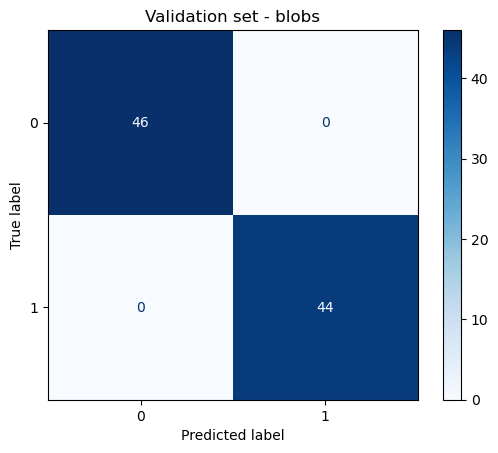


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        44

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [201]:
model = LogRegNNet(0.05,10000,0.01)
model.train(X_train1, y_train1)
predictions1 = model.predict(X_val1)

accuracy = accuracy_score(y_val1, predictions1)
cm = confusion_matrix(y_val1, predictions1)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val1, predictions1, target_names=["0", "1"]))

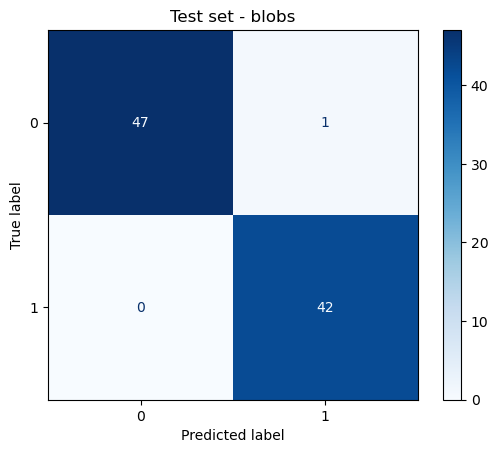


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.9888888888888889
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        48
           1       0.98      1.00      0.99        42

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



In [202]:
predictions1 = model.predict(X_test1)

accuracy = accuracy_score(y_test1, predictions1)
cm = confusion_matrix(y_test1, predictions1)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test1, predictions1, target_names=["0", "1"]))

### Grpahing test Blobs predictions

In [203]:
print(f"The dimensions of the dataset are: {np.shape(X_test1)}")

The dimensions of the dataset are: (90, 3)


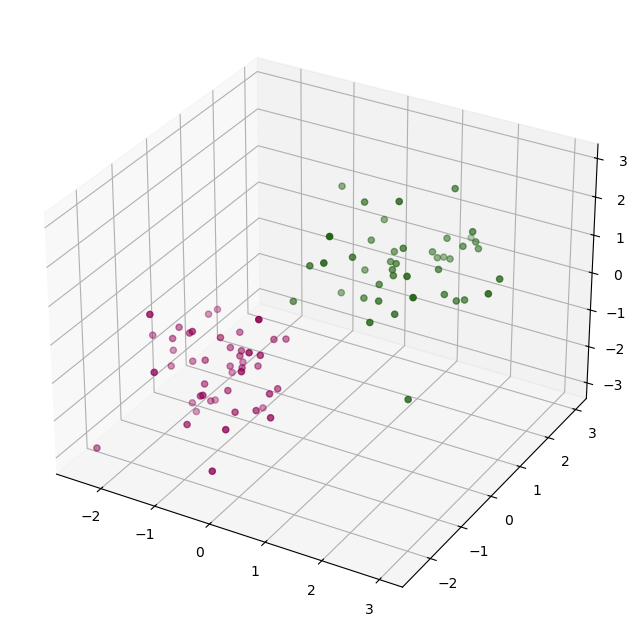

In [204]:
# code form "load-small-datasets"
X_test1 = X_test1.values
fig = plt.figure(figsize=(8, 8)) 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_test1[:,0], X_test1[:,1], X_test1[:,2], c=predictions1, cmap="PiYG") 

plt.show()
plt.close(fig)

### training and testing - circles

iterations total:  54250


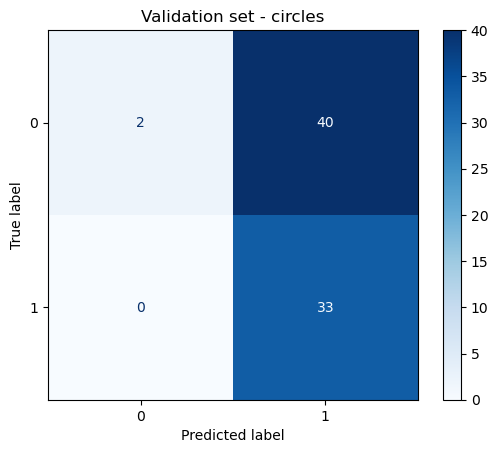


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.4666666666666667
              precision    recall  f1-score   support

           0       1.00      0.05      0.09        42
           1       0.45      1.00      0.62        33

    accuracy                           0.47        75
   macro avg       0.73      0.52      0.36        75
weighted avg       0.76      0.47      0.32        75



In [205]:
model = LogRegNNet(0.05,100000,0.01)
model.train(X_train2, y_train2)
predictions2 = model.predict(X_val2)

accuracy = accuracy_score(y_val2, predictions2)
cm = confusion_matrix(y_val2, predictions2)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - circles")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val2, predictions2, target_names=["0", "1"]))

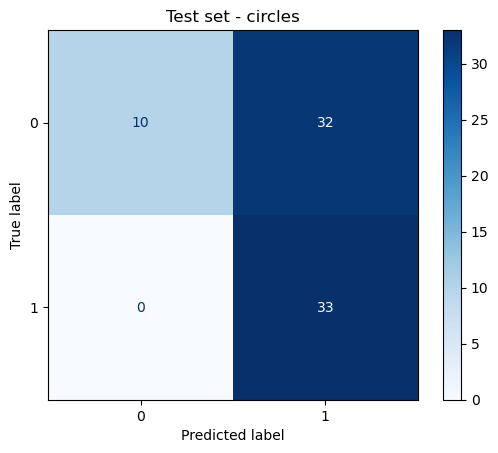


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.5733333333333334
              precision    recall  f1-score   support

           0       1.00      0.24      0.38        42
           1       0.51      1.00      0.67        33

    accuracy                           0.57        75
   macro avg       0.75      0.62      0.53        75
weighted avg       0.78      0.57      0.51        75



In [206]:
predictions2 = model.predict(X_test2)

accuracy = accuracy_score(y_test2, predictions2)
cm = confusion_matrix(y_test2, predictions2)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - circles")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test2, predictions2, target_names=["0", "1"]))

### Grpahing test circles predictions

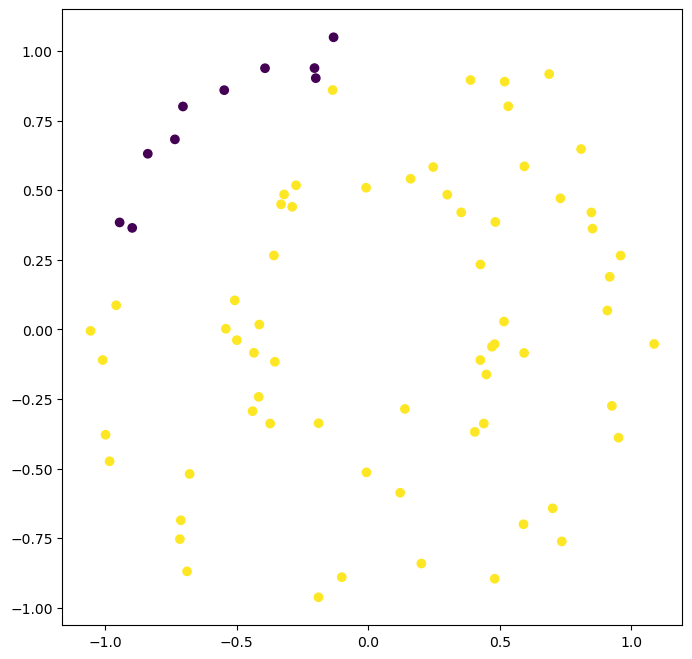

In [207]:
fig, ax = plt.subplots(figsize=(8, 8)) 
X_test2 = X_test2.values
ax.scatter(X_test2[:,0], X_test2[:,1], c=predictions2) 

plt.show()
plt.close(fig)

Here we can see that the blobs dataset is capable of achieving good scores using logistic regression as it is linerly seperable.
on the other hand, using logisitc regression the circles dataset isnt able to score well as it is not linearly seperaeble.

we can see this in how for the blobs dataset two clear groups exist within the plot shown.
On the otherhand the two groups predicted in the circles dataset changes each time the funciton is called.

## rough work

In [208]:
#all of this is for batch gradient descent all the values are used
"""
#this will go into output layerself.layer1
        # basically the x for out output layer
        hiddenLayer = []

        # matrix multiplicaiton to avoid recalling the same funciton
        weightsHL = [[np.random.uniform(0,0.01) for _ in range(self.layer1)] for _ in range(X.shape[1])]

        #gives me two biases for our example one per nueron
        biasHL = [np.random.uniform(0,0.01) for _ in range(self.layer1)]

        # this returns an array 
        # cols = (eventually we will have a single col which will be the value that deteremines 0 or 1)
        # that is rows = inputs (we will need each entry to be able to recieve a class)
        z1 = np.dot(X, weightsHL) + biasHL
        a1 = logReg(z1)

        #z1 is the inputs from both nuerons into hidden layer
        # in this example 2 nuerons for the hidden layer 
        # each nuerons output is a feature and each row is a sample col being feature 1 feature 2
        weightsOL = [np.random.uniform(0,0.01) for _ in range(self.layer1)]

        biasOL=np.random.uniform(0,0.01)

        z2 = np.dot(a1, weightsOL) + biasOL
        a2 = logReg(z2)
"""

"""
        chosenIndex = np.random.randint(0,len(X))

        xi = X.iloc[chosenIndex]
        yi = Y.iloc[chosenIndex]

        z1 = np.dot(xi, weightsHL) + biasHL
        print("z1 :", z1 )
        a1 = logReg(z1)
        print("z1 :", z1 )
        print("a1 :", a1 )
        z2 = np.dot(a1, weightsOL)
        print("z2 :", z2 )
        a2 = logReg(z2)
        print("a2 :", a2 )
"""


"""
while(going):
            # CHoose random sample
            chosenIndex = np.random.randint(0,len(X))

            xi = X.iloc[chosenIndex]
            yi = Y.iloc[chosenIndex]

            # forward pass
            z1 = np.dot(xi, weightsHL) + biasHL
            a1 = logReg(z1)
            
            z2 = np.dot(a1, weightsOL)
            a2 = logReg(z2)

            J_current = lossfunction(yi, a2)

            #graident descent
            # initialise
            deltaWOL = [0] * X.shape[1]
            deltaBOL = 0

            deltaWHL = [[0 for _ in range(self.layer1)] for _ in range(X.shape[1])]
            
            #print(deltaWHL)
            # getting deltas ==================================
            dz2 = a2 - yi

            for j,_ in enumerate(weightsOL):
                deltaWOL[j] = dz2 * a1.iloc[j]

            deltaBOL = dz2

            for j,item in weightsHL:
                deltaWHL[j][0] = dz2 * weightsOL[j] * (a1[0] * (1 - a1[0])) 
                deltaWHL[j][1] = dz2 * weightsOL[j] * (a1[1] * (1 - a1[1])) 

            #for 

            # getting updated ====================================


            for j,_ in enumerate(weightsOL):
                weightsOL[j] = weightsOL[j] - (self.alpha * deltaWOL[j])

            biasOL = biasOL - (self.alpha * deltaBOL)







            


            # stoping critea =========
            iteration +=1
            if(iteration > self.max_iters):
                going = False

            J_running += J_current

            if (iteration%N == 0):
                if (abs(J_running - J_running_prev) < self.threshold):
                    going = False
                print(J_running, " for iteration ", iteration)
                J_running_prev = J_running
                J_running = 0;
"""


"""
# actual process =========================================
        
        chosenIndex = np.random.randint(0,len(X))

        xi = X.iloc[chosenIndex]
        xi = np.array(xi)
        yi = Y.iloc[chosenIndex]

        print("sample :" , xi)
        print("true answer :" , yi)

        # forward pass
        z1 = np.dot(xi, weightsHL) + biasHL
        a1 = logReg(z1)
        print("z1 :", z1 )
        print("a1 :", a1 )
            
        z2 = np.dot(a1, weightsOL)
        a2 = logReg(z2)
        print("z2 :", z2 )
        print("a2 :", a2 )
        print("")

        J_current = lossfunction(yi, a2)

        #graident descent

        #error for layer 2
        dz2 = a2 - yi
        #error for layer 1
        dz1 = dz2 * weightsOL * activaitonDer(z1)
        
        # initialise
        deltaWOL = [0] * X.shape[1]
        deltaWOL = np.array(deltaWOL)
        deltaBOL = 0

        print("delta weights ol shape:" , deltaWOL.shape)
        print("difference per nueron:" , dz1)

        
        #calculate deltas
        #output layer
        deltaWOL = a1 * dz2
        deltaBOL = dz2
        print(deltaWOL)

        #hidden layer
        deltaWHL = xi[:, None] * dz1[None, :] 
        deltaBHL = dz1

        print("delta hidden layers weights: " , deltaWHL)
        print("delta hidden layers bias:", deltaBHL)

        print("")
        print("")

        print("--------------------------------------")
        print("weights hl")
        print(weightsHL)
        print("bias hl")
        print(weightsHL)
        
        print("weights ol")
        print(weightsOL)
        print("bias ol")
        print(biasOL)
        print("--------------------------------------")

        

        #apply updates
        #output layer
        weightsOL = weightsOL - (self.alpha * deltaWOL)
        biasOL = biasOL - (self.alpha * deltaBOL)

        weightsHL = weightsHL - (self.alpha * deltaWHL)
        biasHL = biasHL - (self.alpha * deltaBHL)
        
        print("")
        print("")

        print("--------------------------------------")
        print("weights hl")
        print(weightsHL)
        print("bias hl")
        print(weightsHL)
        
        print("weights ol")
        print(weightsOL)
        print("bias ol")
        print(biasOL)
        print("--------------------------------------")
"""

'\n# actual process =========================================\n        \n        chosenIndex = np.random.randint(0,len(X))\n\n        xi = X.iloc[chosenIndex]\n        xi = np.array(xi)\n        yi = Y.iloc[chosenIndex]\n\n        print("sample :" , xi)\n        print("true answer :" , yi)\n\n        # forward pass\n        z1 = np.dot(xi, weightsHL) + biasHL\n        a1 = logReg(z1)\n        print("z1 :", z1 )\n        print("a1 :", a1 )\n            \n        z2 = np.dot(a1, weightsOL)\n        a2 = logReg(z2)\n        print("z2 :", z2 )\n        print("a2 :", a2 )\n        print("")\n\n        J_current = lossfunction(yi, a2)\n\n        #graident descent\n\n        #error for layer 2\n        dz2 = a2 - yi\n        #error for layer 1\n        dz1 = dz2 * weightsOL * activaitonDer(z1)\n        \n        # initialise\n        deltaWOL = [0] * X.shape[1]\n        deltaWOL = np.array(deltaWOL)\n        deltaBOL = 0\n\n        print("delta weights ol shape:" , deltaWOL.shape)\n        pr



## Task 3 - implement and test a shallow neural network


In [270]:
class NetNsingle:
    def __init__(self,alpha, max_iters, threshold, layer1):
        self.alpha = alpha
        self.max_iters = max_iters
        self.threshold = threshold
        self.layer1 = layer1

        #hidden layer weights and biases
        self.weightsHL = []
        self.biasHL = []
        
        self.weightsOL = []
        self.biasOL = 0

    def train(self, X, Y):
        N = X.shape[0]

        #this will go into output layerself.layer1
        # basically the x for out output layer
        hiddenLayer = []

        # per nueron we have a set of weights
        # each weight corresponds to a feature, 
        weightsHL = [[np.random.uniform(0,0.001) for _ in range(self.layer1)] for _ in range(X.shape[1])]
        weightsHL = np.array(weightsHL)

        #gives me two biases for our example one per nueron
        biasHL = [np.random.uniform(0,0.001) for _ in range(self.layer1)]
        biasHL = np.array(biasHL)
      
        # the nueron outputs are features so need 2 weights
        weightsOL = [np.random.uniform(0,0.001) for _ in range(self.layer1)]
        weightsOL = np.array(weightsOL)

        biasOL=np.random.uniform(0,0.001)

        #stopping criteria
        going = True
        J_running = 0
        J_running_prev=0
        iteration = 0

        # actual process =========================================

        while(going):
            # CHoose random sample
            chosenIndex = np.random.randint(0,len(X))

            xi = X.iloc[chosenIndex]
            xi = np.array(xi)
            yi = Y.iloc[chosenIndex]

            # forward pass
            z1 = np.dot(xi, weightsHL) + biasHL
            a1 = logReg(z1)
            
            z2 = np.dot(a1, weightsOL)
            a2 = logReg(z2)

            J_current = lossfunction(yi, a2)
            #graident descent

            #error for layer 2
            dz2 = a2 - yi
            #error for layer 1
            dz1 = dz2 * weightsOL * activaitonDer(z1)
        
            # initialise
            deltaWOL = [0] * X.shape[1]
            deltaWOL = np.array(deltaWOL)
            deltaBOL = 0
        
            #calculate deltas
            #output layer
            deltaWOL = a1 * dz2
            deltaBOL = dz2
            

            #hidden layer
            deltaWHL = xi[:, None] * dz1[None, :] 
            deltaBHL = dz1

            #apply updates
            #output layer
            weightsOL = weightsOL - (self.alpha * deltaWOL)
            biasOL = biasOL - (self.alpha * deltaBOL)

            weightsHL = weightsHL - (self.alpha * deltaWHL)
            biasHL = biasHL - (self.alpha * deltaBHL)
        

            iteration +=1
            if(iteration > self.max_iters):
                going = False

            J_running += J_current

            if (iteration%N == 0):
                if (abs(J_running - J_running_prev) < self.threshold):
                    going = False
                #print(J_running, " for iteration ", iteration)
                J_running_prev = J_running
                J_running = 0;

            

        self.weightsHL = weightsHL
        self.biasHL = biasHL        
        self.weightsOL = weightsOL
        self.biasOL = biasOL

        #print(z1)
        print("iterations total: " ,iteration)
        print("")
        return weightsHL, biasHL, weightsOL, biasOL

    def predict(self, X):

        y_output = [] 
        X = np.array(X)

        z1 = np.dot(X, self.weightsHL) + self.biasHL
        a1 = logReg(z1)

        z2 = np.dot(a1, self.weightsOL) + self.biasOL
        a2 = logReg(z2)

        for x in a2:
            if x < 0.5:
                y_output.append(0)
            else:
                y_output.append(1)

        return y_output
        

### training and testing - blobs

iterations total:  100001



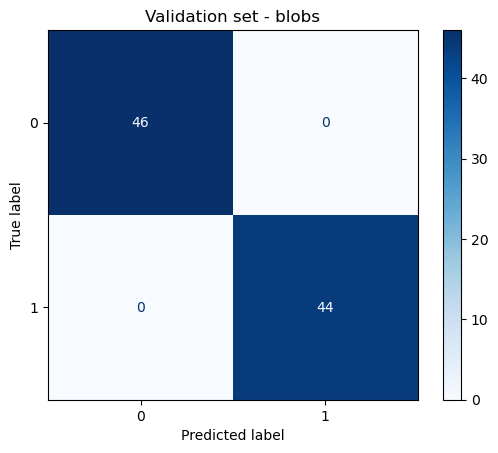


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        44

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [289]:
model = NetNsingle(0.01,100000,0.01,15)
model.train(X_train1, y_train1)
predictions3 = model.predict(X_val1)

accuracy = accuracy_score(y_val1, predictions3)
cm = confusion_matrix(y_val1, predictions3)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val1, predictions3, target_names=["0", "1"]))


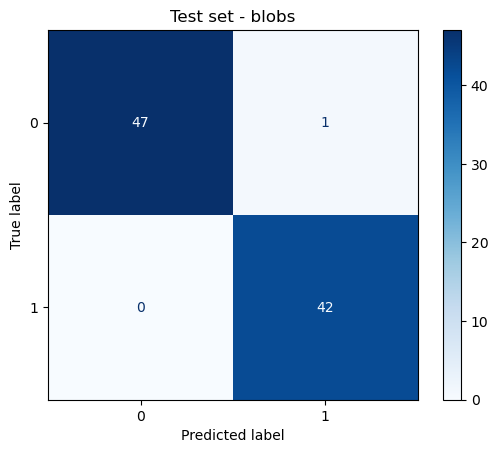


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.9888888888888889
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        48
           1       0.98      1.00      0.99        42

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90



In [290]:
predictions4 = model.predict(X_test1)

accuracy = accuracy_score(y_test1, predictions4)
cm = confusion_matrix(y_test1, predictions4)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - blobs")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test1, predictions4, target_names=["0", "1"]))

### training and testing - circles

iterations total:  351750



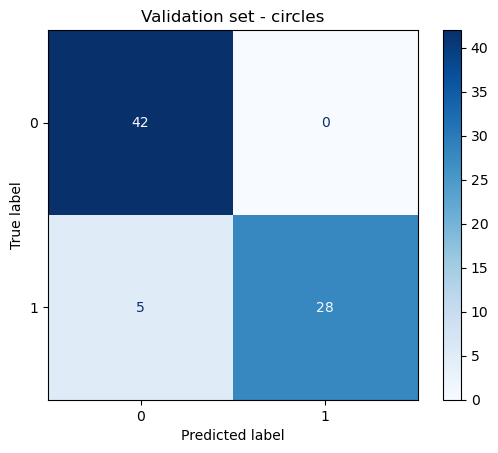


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        42
           1       1.00      0.85      0.92        33

    accuracy                           0.93        75
   macro avg       0.95      0.92      0.93        75
weighted avg       0.94      0.93      0.93        75



In [296]:
model = NetNsingle(0.1,500000,0.001,100)
model.train(X_train2, y_train2)
predictions3 = model.predict(X_val2)

accuracy = accuracy_score(y_val2, predictions3)
cm = confusion_matrix(y_val2, predictions3)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Validation set - circles")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_val2, predictions3, target_names=["0", "1"]))

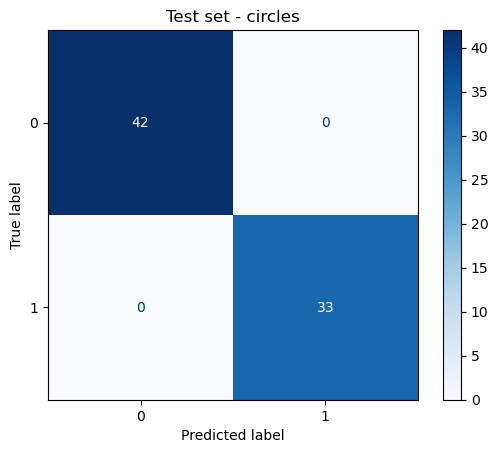


-------------------------------------numerical Scores----------------------------------------------

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        33

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [297]:
predictions4 = model.predict(X_test2)

accuracy = accuracy_score(y_test2, predictions4)
cm = confusion_matrix(y_test2, predictions4)
cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm.plot(cmap="Blues")
plt.title("Test set - circles")
plt.show()
print("")
print("-------------------------------------numerical Scores----------------------------------------------")
print("")
print(f'Accuracy: {accuracy}')
print( classification_report(y_test2, predictions4, target_names=["0", "1"]))

### results

For the coded nueral netowrk with a single layer we can see much better outcomes with the given sets of data.
the blobs data set was able to be trained and was able to achieve good scores on training and validaiton almost immediately.

On the other hand the circles dataset too far more training. surpirzingly the model would collapse (predict all 1s or 0s) quite often with a very low alpha score for the circle dataset, however with a higher alpha the model is able to train with much larger steps and was able to achieve consistanly good scores in the validation set. The model was also abe to even better scores in the training set.

its clear that the NN model is far superior to the simple logestic regression model as its scores on the non-linearly seperable dataset easily climb above the logistic regression model.

changing the number of nodes also makes the model far more stable. Due to SGD the model can at times collapse and predict only 1s or 0s if the number of nodes is low.
however as the number of nodes increases the likelyhood of this occuring decreases, for the first dataset this problem seemed to be resolved with very few nodes (10-15), however for the second dataset much more nodes wehere needed to successfully train the model

## Task 4

### read in EMNIST

In [298]:
#code from "load-EMNIST-letters"
data = np.load("emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]

In [300]:
# Extract just two classes from the dataset

# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 6   # f
c2 = 14  # n

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [301]:

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))
    
    for i in range(48):
        idx = n + i
        
        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

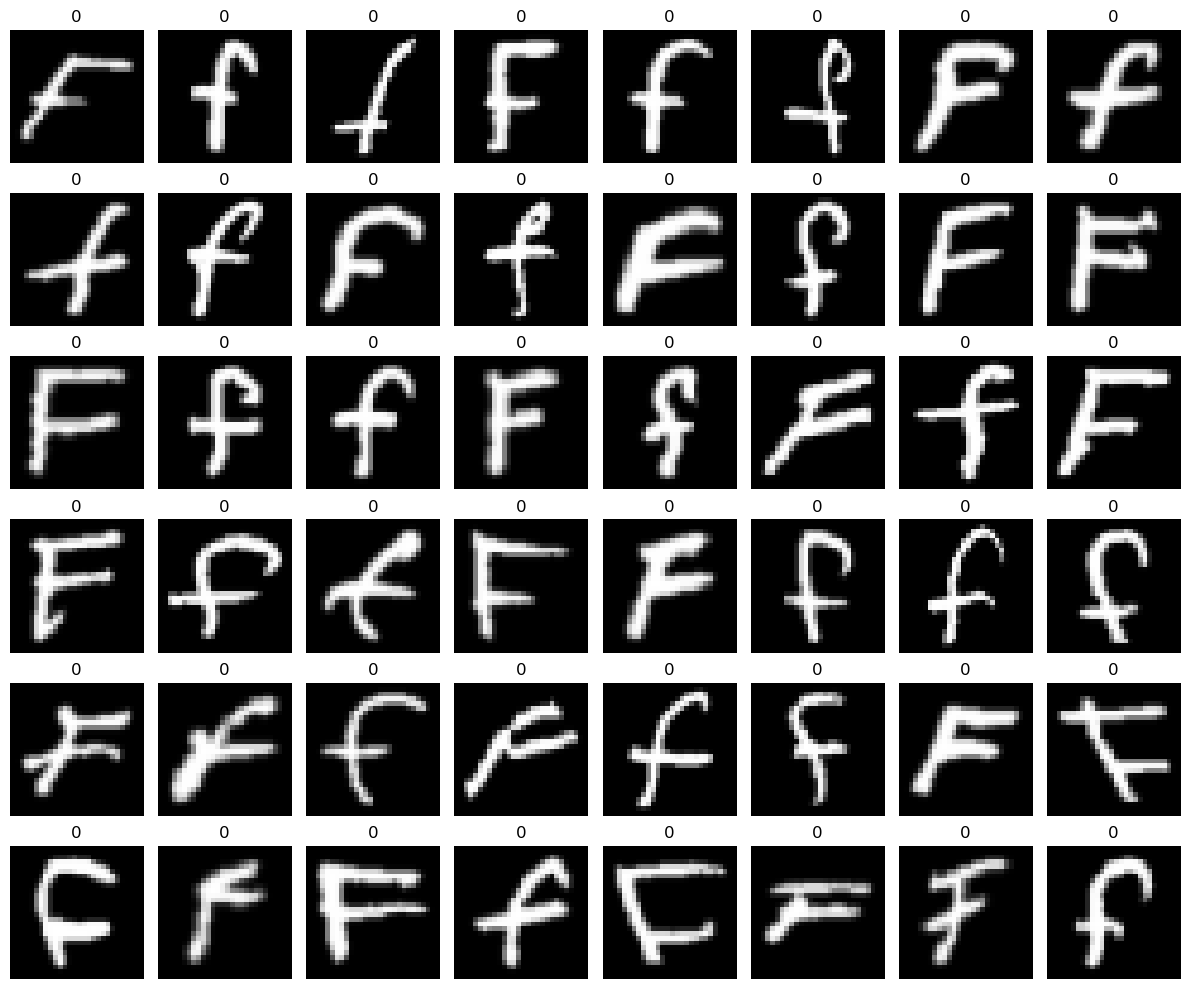

In [302]:
plot_grid(x_binary, y_binary, n=0)

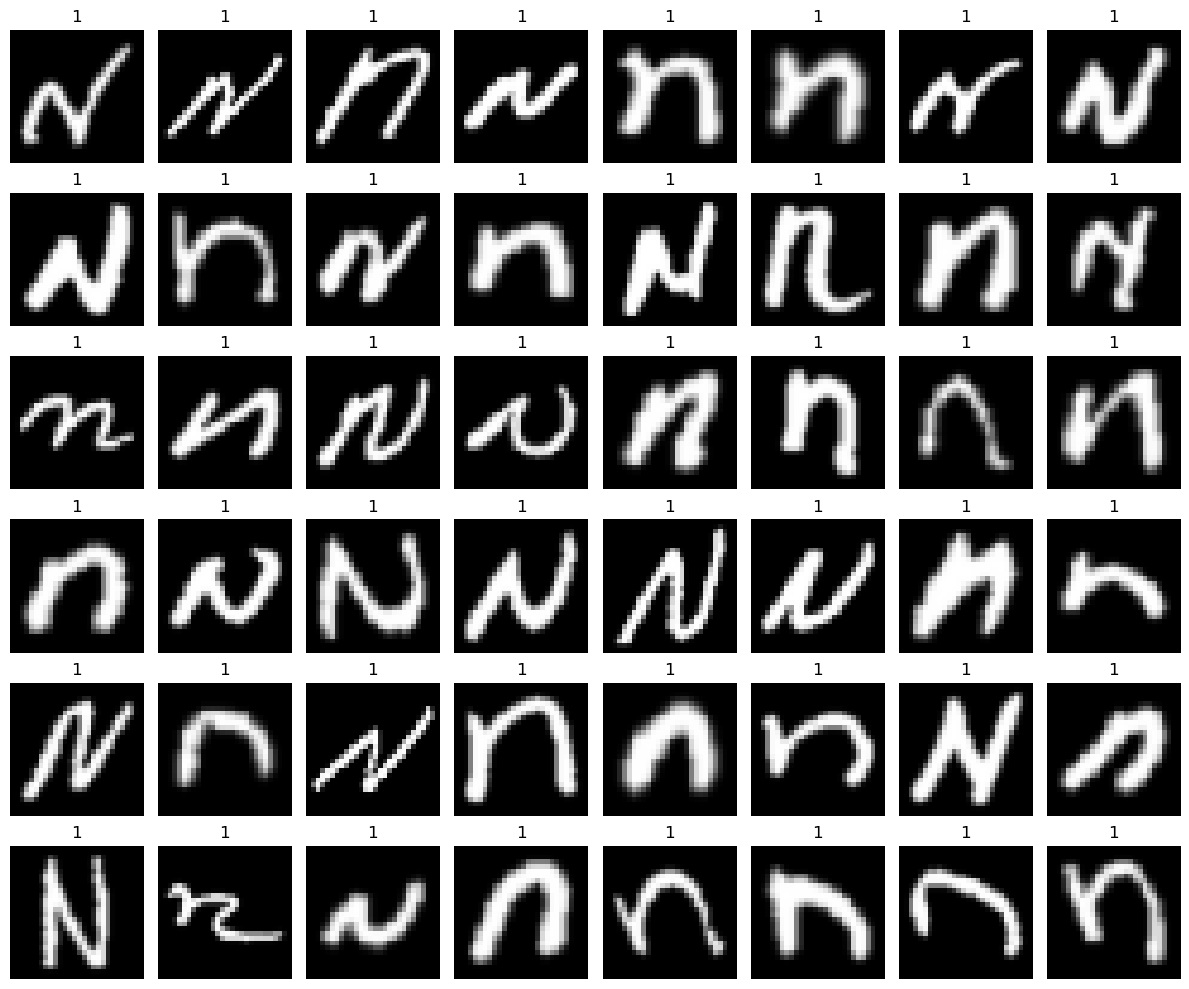

In [303]:
plot_grid(x_binary, y_binary, n=3300)

## Task 5

-------------------------------------numerical Scores----------------------------------------------

Accuracy: 0.8933333333333333
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        42
           1       1.00      0.76      0.86        33

    accuracy                           0.89        75
   macro avg       0.92      0.88      0.89        75
weighted avg       0.91      0.89      0.89        75